# Proyecto 1 - Análisis exploratorio

Diego Andrés Morales Aquino <br>
21762

In [5]:
from ydata_profiling import ProfileReport
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
data = pd.read_csv("dataset_feature_engineering.csv")

## Análisis exploratorio

In [7]:
# Número de features
print(f"Total de features: {len(data.columns)}")
# Número de registros
print(f"Total de registros: {len(data)}")

Total de features: 35
Total de registros: 1852394


In [8]:
# Desplegar primeras filas del dataset
data.head(5)

,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,first_time_at_merchant,dist_between_client_and_merch,trans_month,trans_day,hour,year,times_shopped_at_merchant,times_shopped_at_merchant_year,times_shopped_at_merchant_month,times_shopped_at_merchant_day
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,...,True,78.773821,1,1,0,2019,5,4,2,1
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,...,True,30.216618,1,1,0,2019,4,4,1,1
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,...,True,108.102912,1,1,0,2019,4,3,1,1
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,...,True,95.685115,1,1,0,2019,1,1,1,1
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,...,True,77.702395,1,1,0,2019,6,1,1,1


In [4]:
# Observar el tipo de datos de cada columna
data.dtypes

cc_num                               int64
merchant                            object
category                            object
amt                                float64
first                               object
last                                object
gender                              object
street                              object
city                                object
state                               object
zip                                  int64
lat                                float64
long                               float64
city_pop                             int64
job                                 object
dob                                 object
trans_num                           object
unix_time                            int64
merch_lat                          float64
merch_long                         float64
is_fraud                             int64
amt_month                          float64
amt_year                           float64
amt_month_s

In [50]:
#report = ProfileReport(data)
#report

In [51]:
#report.to_file("dataset_profile_report.html")

### Frecuencia por categoría

In [52]:
category_freq = data['category'].value_counts().reset_index()
category_freq.columns = ['category', 'count']

print(category_freq)


          category   count
0    gas_transport  188029
1      grocery_pos  176191
2             home  175460
3     shopping_pos  166463
4        kids_pets  161727
5     shopping_net  139322
6    entertainment  134118
7      food_dining  130729
8    personal_care  130085
9   health_fitness  122553
10        misc_pos  114229
11        misc_net   90654
12     grocery_net   64878
13          travel   57956


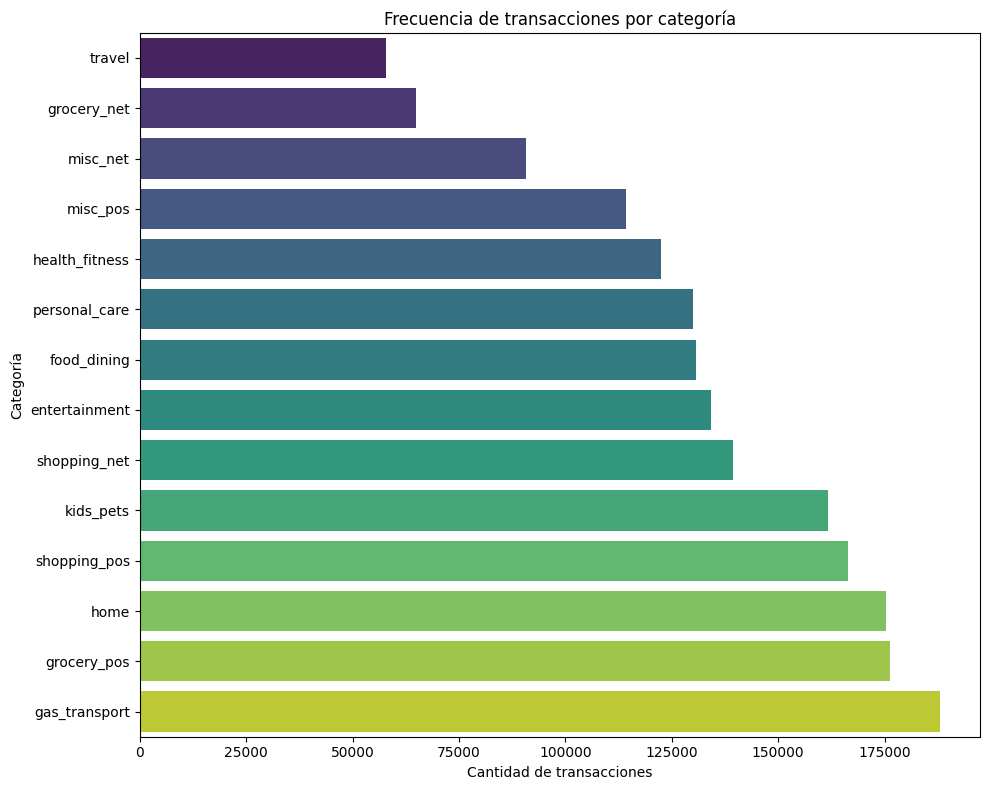

In [53]:
# Agrupar y contar categorías
category_counts = data['category'].value_counts().sort_values(ascending=True)

# Crear un DataFrame para usar `hue` correctamente (aunque no haya grupos)
category_df = category_counts.reset_index()
category_df.columns = ['category', 'count']
category_df['hue'] = category_df['category']  # Dummy hue para aplicar el palette

# Plot sin warning
plt.figure(figsize=(10, 8))
sns.barplot(data=category_df, x='count', y='category', hue='hue', palette='viridis', dodge=False, legend=False)
plt.title('Frecuencia de transacciones por categoría')
plt.xlabel('Cantidad de transacciones')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()


### Cantidad de transacciones legítimas vs fraudulentas

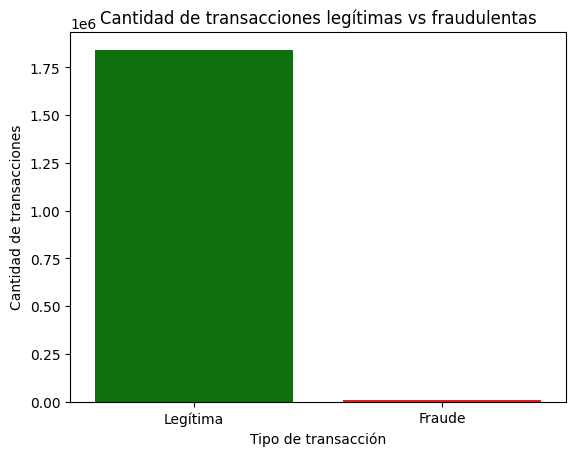

In [54]:
# Crear un DataFrame con los valores
fraud_df = pd.DataFrame({
    'Tipo': ['Legítima', 'Fraude'],
    'Cantidad': data['is_fraud'].value_counts().sort_index().values
})

# Gráfico con hue explícito
sns.barplot(data=fraud_df, x='Tipo', y='Cantidad', hue='Tipo', palette={'Legítima': 'green', 'Fraude': 'red'}, legend=False)
plt.title('Cantidad de transacciones legítimas vs fraudulentas')
plt.ylabel('Cantidad de transacciones')
plt.xlabel('Tipo de transacción')
plt.show()


### Distribución de transacciones por hora

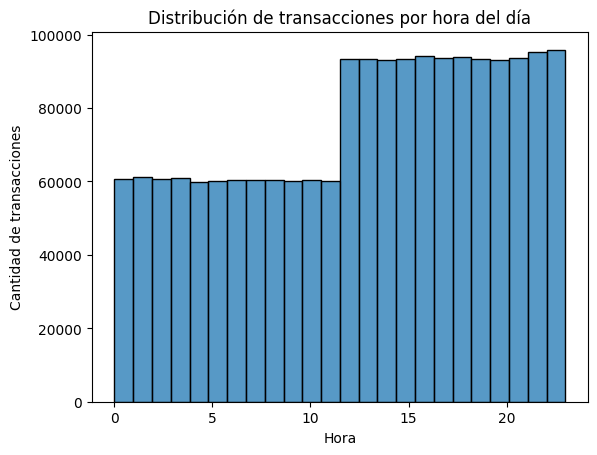

In [55]:
sns.histplot(data=data, x='hour', bins=24, kde=False)
plt.title('Distribución de transacciones por hora del día')
plt.xlabel('Hora')
plt.ylabel('Cantidad de transacciones')
plt.show()


Se muestra a qué horas del día se concentran las transacciones. Analizar la distribución horaria es útil para detectar patrones anómalos, ya que los fraudes tienden a ocurrir fuera del horario hábil, como en la madrugada.

### Distribución del monto de transacciones (utilizando escala log)

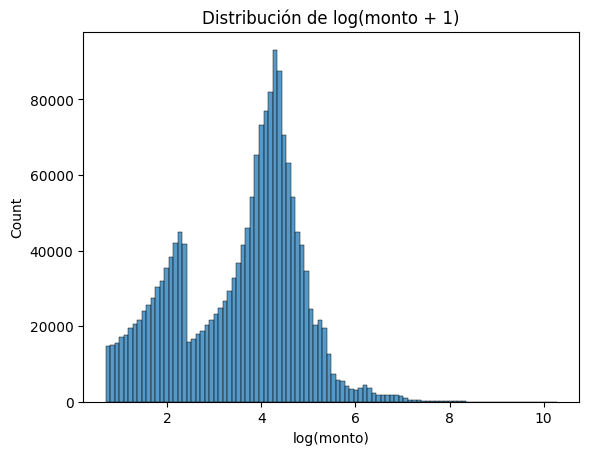

In [9]:
sns.histplot(np.log1p(data['amt']), bins=100)
plt.title('Distribución de log(monto + 1)')
plt.xlabel('log(monto)')
plt.show()

El monto de las transacciones puede variar ampliamente. En esta gráfico se puede observar tanto los valores comunes como los extremos. Esta información ayuda a detectar si los fraudes se asocian con montos atípicos. Se está utilizando una escala logarítmica para poder visualizar de mejor manera.

### Porcentaje de fraudes por categoría de comercio

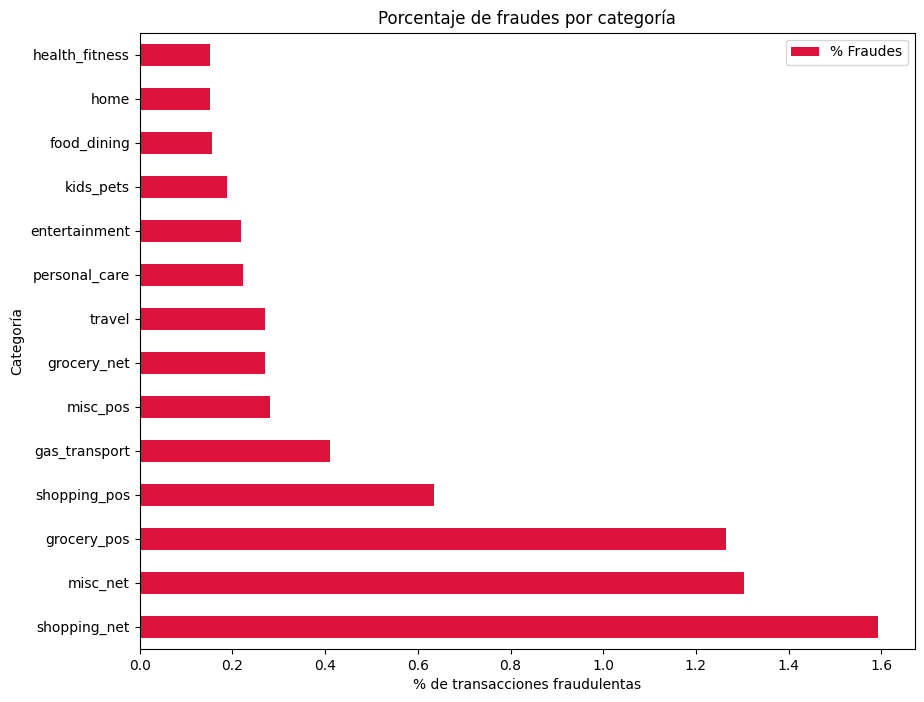

In [ ]:
category_fraud_freq = data.groupby(['category', 'is_fraud']).size().unstack(fill_value=0)
category_fraud_freq.columns = ['Legítimas', 'Fraudes']
category_fraud_freq['Total'] = category_fraud_freq.sum(axis=1)
category_fraud_freq['% Fraudes'] = (category_fraud_freq['Fraudes'] / category_fraud_freq['Total']) * 100
category_fraud_freq.sort_values('% Fraudes', ascending=False)[['% Fraudes']].plot(kind='barh', figsize=(10, 8), color='crimson')

plt.title('Porcentaje de fraudes por categoría')
plt.xlabel('% de transacciones fraudulentas')
plt.ylabel('Categoría')
plt.show()


Este gráfico permite identificar en qué categorías comerciales se concentran más fraudes proporcionalmente. Las transacciones por internet tiene una mayor posibilidad de transacciones fraudulentas. Mientras que, la categoría de viajes posee un nivel medio-bajo de transacciones de fraude.

### Monto promedio por tipo de transacción

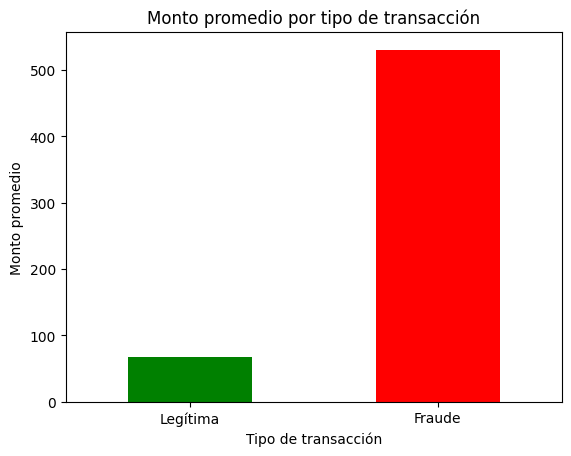

In [ ]:
data.groupby('is_fraud')['amt'].mean().plot(kind='bar', color=['green', 'red'])
plt.title('Monto promedio por tipo de transacción')
plt.xlabel('Tipo de transacción')
plt.ylabel('Monto promedio')
plt.xticks([0, 1], ['Legítima', 'Fraude'], rotation=0)
plt.show()


Se puede observar que las transacciones fraudulentas generalmente presentan montos mucho más elevados que las legítimas en promedio.

### Cuántas veces se ha comprado en un comercio: legítimo vs fraude

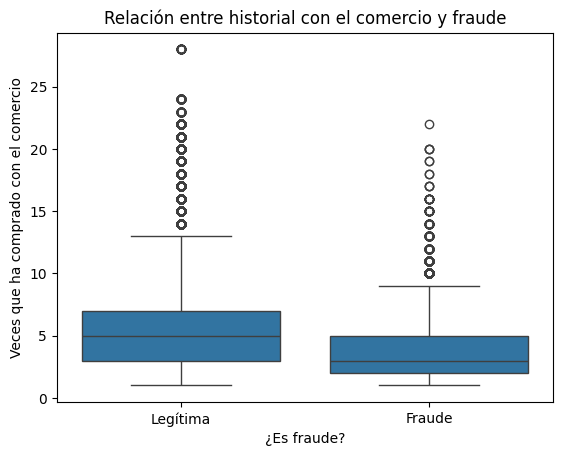

In [ ]:
sns.boxplot(x='is_fraud', y='times_shopped_at_merchant', data=data)
plt.title('Relación entre historial con el comercio y fraude')
plt.xlabel('¿Es fraude?')
plt.ylabel('Veces que ha comprado con el comercio')
plt.xticks([0, 1], ['Legítima', 'Fraude'])
plt.show()


Se observa que las transacciones fraudulentas tienden a concentrarse en clientes con un menor número de compras previas en un comercio, en comparación con las transacciones legítimas.

### Ubicación geográfica por tipo de transacción

C:\Users\diego\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


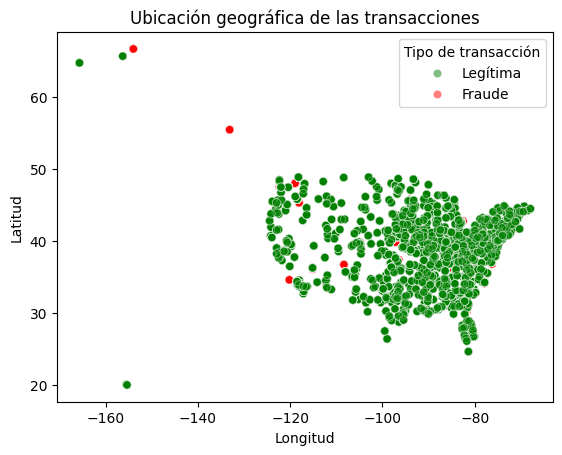

In [ ]:
data['fraud_label'] = data['is_fraud'].map({0: 'Legítima', 1: 'Fraude'})

sns.scatterplot(
    data=data,
    x='long', 
    y='lat', 
    hue='fraud_label', 
    palette={'Legítima': 'green', 'Fraude': 'red'},
    alpha=0.5
)

plt.title('Ubicación geográfica de las transacciones')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Tipo de transacción')
plt.show()



No se puede observar una tendencia clara de una ubicación geográfica en donde se concentren las transacciones fraudulentas. Sin embargo, resulta interesante que se puede apreciar la forma de los EEUU al resaltar la ubicación de las transacciones.

### Transacciones de categoría viajes en el tiempo

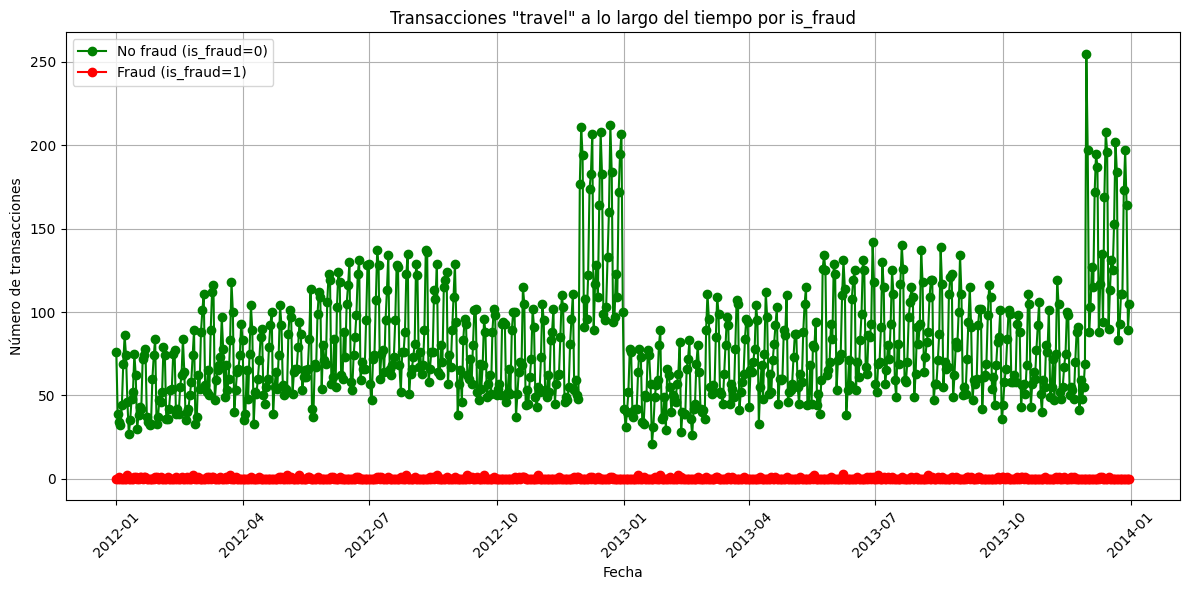

In [ ]:
# Filtrar solo categoría 'travel'
travel_data = data[data['category'] == 'travel']

# Convertir unix_time a datetime sin modificar el df original
timestamps = pd.to_datetime(travel_data['unix_time'], unit='s')
travel_data = travel_data.assign(date=timestamps.dt.date)

# Contar transacciones diarias por is_fraud
counts_by_fraud = travel_data.groupby(['date', 'is_fraud']).size().unstack(fill_value=0).sort_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(counts_by_fraud.index, counts_by_fraud.get(0, pd.Series()), 
         marker='o', linestyle='-', color='green', label='No fraud (is_fraud=0)')
plt.plot(counts_by_fraud.index, counts_by_fraud.get(1, pd.Series()), 
         marker='o', linestyle='-', color='red', label='Fraud (is_fraud=1)')

plt.xlabel('Fecha')
plt.ylabel('Número de transacciones')
plt.title('Transacciones "travel" a lo largo del tiempo por is_fraud')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


En este gráfico se pueden observar la distribución de transacciones legítimas y fraudulentas a lo largo del tiempo. Se aprecia que la proporción de transacciones fraudulentas se mantiene muy reducida en comparación a las transacciones legítimas durante todo el periodo de tiempo.

### Transacciones de categoría viajes (fraude) en el tiempo

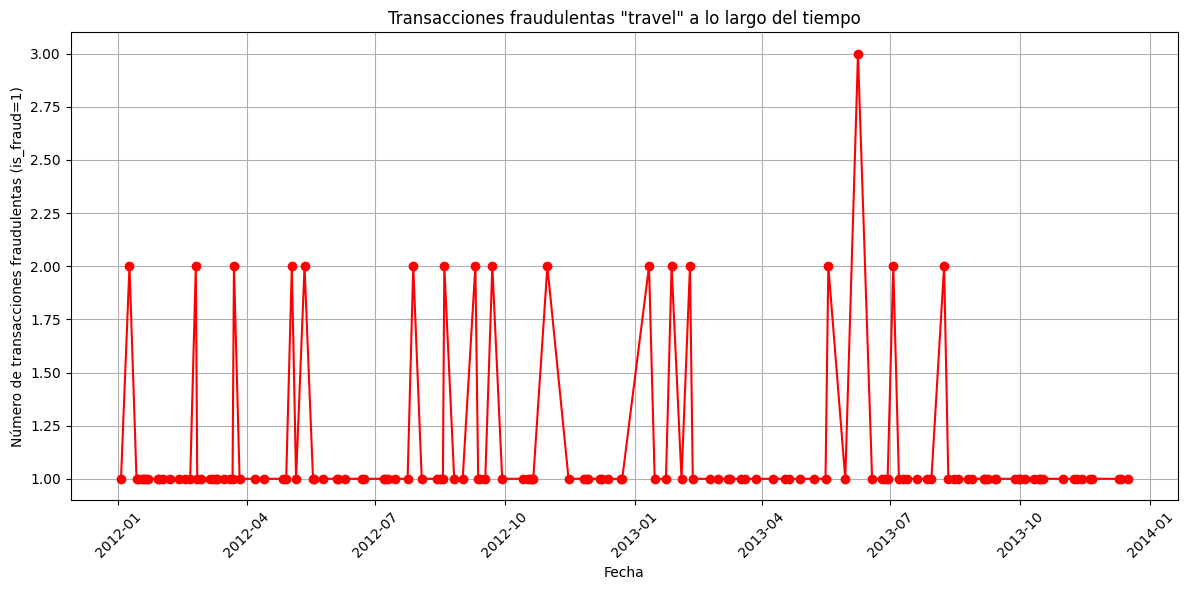

In [3]:
# Filtrar categoría 'travel' y solo transacciones fraudulentas (is_fraud=1)
fraud_data = data[(data['category'] == 'travel') & (data['is_fraud'] == 1)]

# Convertir unix_time a datetime sin modificar el df original
timestamps = pd.to_datetime(fraud_data['unix_time'], unit='s')
fraud_data = fraud_data.assign(date=timestamps.dt.date)

# Contar transacciones diarias
daily_fraud_counts = fraud_data['date'].value_counts().sort_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(daily_fraud_counts.index, daily_fraud_counts.values, marker='o', linestyle='-', color='red')
plt.xlabel('Fecha')
plt.ylabel('Número de transacciones fraudulentas (is_fraud=1)')
plt.title('Transacciones fraudulentas "travel" a lo largo del tiempo')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


El gráfico muestra que las transacciones fraudulentas en la categoría "travel" son poco frecuentes y suelen ser aisladas (una por día), aunque hay picos ocasionales con hasta 3 fraudes en un solo día, destacando posibles momentos de mayor actividad fraudulenta.

## Data engineering

In [193]:
# Ordenar por número de tarjeta y tiempo de la transacción
data = data.sort_values(by=['cc_num', 'unix_time']).reset_index(drop=True)

### amt_avg_per_visit_to_merchant

Calcular el monto promedio gastado en cada visita a un comercio específico. Será útil para detectar patrones inusuales en el gasto: por ejemplo, si normalmente alguien gasta poco en una agencia de viajes y de pronto hace una compra grande, podría levantar sospechas.

In [194]:
data['amt_avg_per_visit_to_merchant'] = data['amt'] / (data['times_shopped_at_merchant'] + 1)

In [118]:
data['amt_avg_per_visit_to_merchant'].describe()

count    1.852394e+06
mean     1.439028e+01
std      4.671809e+01
min      4.478261e-02
25%      2.056667e+00
50%      7.178750e+00
75%      1.575143e+01
max      1.355989e+04
Name: amt_avg_per_visit_to_merchant, dtype: float64

### amt_ratio_to_month_total
Representa qué porcentaje del gasto mensual total representa la transacción actual. 

In [195]:
data['amt_ratio_to_month_total'] = data['amt'] / (data['amt_month'] + 1)


In [120]:
data['amt_ratio_to_month_total'].describe()

count    1.852394e+06
mean     5.551670e-02
std      1.385907e-01
min      3.097998e-05
25%      4.005020e-03
50%      1.359321e-02
75%      3.982134e-02
max      9.999140e-01
Name: amt_ratio_to_month_total, dtype: float64

### consecutive_transactions_same_merchant
Evalúa si hubo múltiples transacciones con el mismo comercio en un periodo de una hora

In [196]:
data['consecutive_transactions_same_merchant'] = (
    (data['merchant'] == data.groupby('cc_num')['merchant'].shift(1)) &
    (data['unix_time'] - data.groupby('cc_num')['unix_time'].shift(1) < 3600)
).astype(int)

In [122]:
data['consecutive_transactions_same_merchant'].value_counts()

consecutive_transactions_same_merchant
0    1851492
1        902
Name: count, dtype: int64

### relative_distance_vs_previous
Diferencia de distancia respecto a la transacción anterior de la misma tarjeta. Si el usuario suele comprar cerca de su ubicación habitual, una transacción con una distancia totalmente distinta podría ser una señal de fraude.

In [197]:
# Calculars la distancia respecto a la transacción anterior del mismo usuario
data['prev_dist'] = data.groupby('cc_num')['dist_between_client_and_merch'].shift(1)
data['relative_distance_vs_previous'] = (data['dist_between_client_and_merch'] - data['prev_dist']).fillna(0)

# Eliminar la columna temporal
data.drop(columns=['prev_dist'], inplace=True)


In [124]:
data['relative_distance_vs_previous'].describe()

count    1.852394e+06
mean     5.120865e-04
std      4.101586e+01
min     -1.411520e+02
25%     -2.846672e+01
50%      0.000000e+00
75%      2.847191e+01
max      1.379217e+02
Name: relative_distance_vs_previous, dtype: float64

### merchant_entropy_user_level
La diversidad de comercios en los que un usuario ha comprado, usando entropía. Usuarios con perfiles muy consistentes (baja entropía) que repentinamente compran en lugares muy variados podrían estar siendo vulnerados.

In [198]:
from scipy.stats import entropy

def calc_entropy(merchants):
    probs = merchants.value_counts(normalize=True)
    return entropy(probs)

merchant_entropy = data.groupby('cc_num')['merchant'].agg(calc_entropy)
data = data.merge(merchant_entropy.rename('merchant_entropy_user_level'), left_on='cc_num', right_index=True)


In [126]:
data['merchant_entropy_user_level'].describe()

count    1.852394e+06
mean     6.274365e+00
std      1.511986e-01
min      1.560710e+00
25%      6.246483e+00
50%      6.310343e+00
75%      6.364319e+00
max      6.416477e+00
Name: merchant_entropy_user_level, dtype: float64

### has_traveled_far_in_a_day
Evalúa si en ese día el usuario ha comprado desde un lugar a más de 100km de su ubicación habitual.

In [199]:
# Calcula la distancia diaria máxima por tarjeta
daily_max_dist = data.groupby(['cc_num', 'year', 'trans_month', 'trans_day'])['dist_between_client_and_merch'].transform('max')
data['has_traveled_far_in_a_day'] = (daily_max_dist > 100).astype(int)


Text(0.5, 1.0, 'Porcentaje de transacciones con distancia máxima diaria > 100 km')

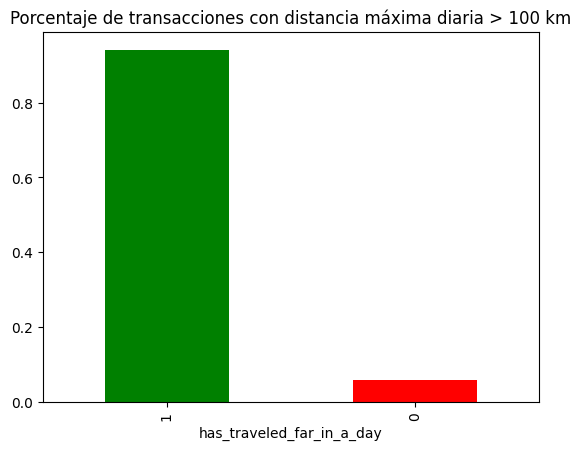

In [144]:
data['has_traveled_far_in_a_day'].value_counts(normalize=True).plot(kind='bar', color=['green', 'red'])
plt.title('Porcentaje de transacciones con distancia máxima diaria > 100 km')

### daily_distance_traveled

Mide la distancia acumulada de las transacciones del cliente en un día.

In [200]:
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    """
    Calcula la distancia en kilómetros entre dos puntos geográficos.
    """
    # Convertir a radianes
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Fórmula de Haversine
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radio de la tierra en km
    return c * r


In [201]:
# Ordenar por tarjeta y tiempo
data = data.sort_values(['cc_num', 'unix_time'])

# Agrupar por usuario y día
group_cols = ['cc_num', 'year', 'trans_month', 'trans_day']
data[['prev_lat', 'prev_long']] = data.groupby(group_cols)[['lat', 'long']].shift(1)

# Calcular distancia entre transacciones consecutivas
data['step_distance'] = data.apply(
    lambda row: haversine(row['prev_long'], row['prev_lat'], row['long'], row['lat'])
    if not pd.isnull(row['prev_lat']) else 0,
    axis=1
)

# Calcular la distancia diaria acumulada
data['daily_distance_traveled'] = data.groupby(group_cols)['step_distance'].transform('sum')

# Eliminar columnas temporales
data.drop(columns=['prev_lat', 'prev_long', 'step_distance'], inplace=True)


### is_travel

In [202]:
# Crear columna booleana para categoría 'viajes'
data['is_travel'] = data['category'].str.lower().isin(['travel', 'airline', 'agency', 'vacation', 'tourism']).astype(int)

### Extraer datos de fecha

In [203]:
# Extraer año, mes, día, hora, minuto, segundo como columnas numéricas
data['datetime'] = pd.to_datetime(data['unix_time'], unit='s')

data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['hour'] = data['datetime'].dt.hour
data['minute'] = data['datetime'].dt.minute
data['second'] = data['datetime'].dt.second

In [204]:
data.head()

,cc_num,merchant,category,amt,first,last,gender,street,city,state,...,relative_distance_vs_previous,merchant_entropy_user_level,has_traveled_far_in_a_day,daily_distance_traveled,is_travel,datetime,month,day,minute,second
0,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,...,0.000000,6.28729,1,0.0,0,2012-01-01 12:47:15,1,1,47,15
1,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,...,-17.426304,6.28729,1,0.0,0,2012-01-02 08:44:57,1,2,44,57
2,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,...,-88.361165,6.28729,1,0.0,0,2012-01-02 08:47:36,1,2,47,36
3,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,...,65.282594,6.28729,1,0.0,0,2012-01-02 12:38:14,1,2,38,14
4,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,...,-12.771544,6.28729,1,0.0,0,2012-01-02 13:10:46,1,2,10,46


## Entrenamiento de modelo

A continuación se prepara el conjunto de datos para un modelo de detección de fraude. Primero se hace una copia de los datos originales y se convierten variables booleanas en numéricas. Luego se codifican variables categóricas para que el modelo pueda procesarlas. Después, se divide el conjunto en entrenamiento y prueba usando una fecha como límite temporal. Finalmente, se seleccionan las columnas que serán usadas como características y la variable objetivo para entrenar y evaluar el modelo.



In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [205]:

# Datos a utilizar
filter_data = data.copy()

#filter_data = filter_data[filter_data['category'] == 'travel']

# Convertir bool a int
filter_data['first_time_at_merchant'] = filter_data['first_time_at_merchant'].astype(int)


# Codificar columnas categóricas que se usan como features
for col in ['category', 'gender', 'merchant', 'street', 'city', 'state', 'job']:
    filter_data[col] = LabelEncoder().fit_transform(filter_data[col])

# Cortar en noviembre de 2013
train_data = filter_data[filter_data['datetime'] < '2013-10-01']
test_data = filter_data[filter_data['datetime'] >= '2013-10-01']

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# Columnas que no se usarán como features
drop_cols = ['is_fraud', 'datetime', 'first', 'last', 'dob', 'trans_num']

# Seleccionar features
features = [col for col in train_data.columns if col not in drop_cols]

X_train = train_data[features]
y_train = train_data['is_fraud']
X_test = test_data[features]
y_test = test_data['is_fraud']

Train data shape: (1570873, 48)
Test data shape: (281521, 48)


### Métricas personalizadas

En la función para evaluar modelo se entrena un modelo LightGBM para clasificación binaria usando una métrica personalizada opcional. Se asignan pesos mayores a las transacciones de la categoría “viaje” para darles más importancia. La función permite ajustar parámetros del modelo, realiza entrenamiento con validación temprana y calcula métricas clave como AUC, F1, precisión, recall y matriz de confusión. Finalmente, devuelve un resumen de los resultados en un DataFrame.

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, fbeta_score, precision_score, recall_score
import lightgbm as lgb

In [230]:
def evaluate_model_with_custom_metric(
    X_train, y_train, X_test, y_test,
    custom_feval=None,
    metric_name=None,
    threshold=0.5,
    params_override=None,
    print_params=False
):
    """
    Entrena un modelo LGBM con el API nativo y métrica personalizada.
    Permite pasar parámetros personalizados y devuelve un DataFrame con métricas.
    """

    # Asignar pesos (3x si es viaje)
    weights_train = 1 + 2 * X_train['is_travel']
    weights_test = 1 + 2 * X_test['is_travel']

    # Crear datasets
    lgb_train = lgb.Dataset(X_train, y_train, weight=weights_train)
    lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train, weight=weights_test)

    # Parámetros por defecto
    params = {
        'objective': 'binary',
        'learning_rate': 0.05,
        'max_depth': 10,
        'num_leaves': 31,
        'min_child_samples': 20,
        'verbosity': -1,
    }

    if params_override:
        params.update(params_override)

    # Entrenamiento
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_eval],
        feval=custom_feval,
        callbacks=[lgb.early_stopping(100)],
    )

    # Predicción
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > threshold).astype(int)

    # Métricas
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    fp_ratio = (tp + fp) / (tp + 1e-9)

    results = pd.DataFrame([{
        'custom_metric': metric_name if metric_name else custom_feval.__name__ if custom_feval else 'default',
        'fp_ratio': fp_ratio,
        'auc': auc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        **(params_override if print_params else {})
    }])

    return results

### Grid search: optimización de hiperparámetros

A continuación se realiza una búsqueda utilizando GridSearch para encontrar los parámetros que mejoren el rendimiento del modelo base.

In [107]:
from itertools import product
from tqdm import tqdm

In [ ]:
from sklearn.model_selection import ParameterSampler
import numpy as np

# Número de muestras aleatorias que deseas
n_iter = 30  # mucho menor que 180

param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'max_depth': [6, 8, 10, 12],
    'num_leaves': [15, 31, 50],
    'min_child_samples': [10, 20, 30],
}

# Generar muestras aleatorias
random_combos = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=42))

# Evaluación como antes
all_results = []

for combo in tqdm(random_combos, desc="Random Search"):
    result_df = evaluate_model_with_custom_metric(
        X_train, y_train, X_test, y_test,
        custom_feval=None,
        metric_name=f"leaves{combo['num_leaves']}_depth{combo['max_depth']}_child{combo['min_child_samples']}_lr{combo['learning_rate']}",
        threshold=0.8,
        params_override=combo,
        print_params=True
    )
    all_results.append(result_df)

gridsearch_results = pd.concat(all_results, ignore_index=True)
print(gridsearch_results.sort_values(by='f1_score', ascending=False).head())


Random Search:   0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[997]	valid_0's binary_logloss: 0.00386831


Random Search:   3%|▎         | 1/30 [01:22<39:48, 82.37s/it]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[885]	valid_0's binary_logloss: 0.00398059


Random Search:   7%|▋         | 2/30 [02:07<28:13, 60.48s/it]

...

Training until validation scores don't improve for 50 rounds


Random Search: 100%|██████████| 30/30 [13:38<00:00, 20.88s/it]

Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0146577


Random Search: 100%|██████████| 30/30 [13:38<00:00, 27.29s/it]

                      custom_metric  fp_ratio       auc  f1_score  precision  \
19  leaves50_depth10_child10_lr0.03  1.067588  0.996172  0.798283   0.936691   
20  leaves31_depth10_child30_lr0.05  1.079389  0.996255  0.797322   0.926450   
7   leaves50_depth12_child20_lr0.03  1.039370  0.995986  0.795739   0.962121   
12  leaves15_depth12_child30_lr0.03  1.033439  0.996986  0.792429   0.967643   
1    leaves15_depth6_child30_lr0.03  1.027508  0.997217  0.786760   0.973228   

      recall   tp  fp      tn   fn  num_leaves  min_child_samples  max_depth  \
19  0.695513  651  44  280541  285          50                 10         10   
20  0.699786  655  52  280533  281          31                 30         10   
7   0.678419  635  25  280560  301          50                 20         12   
12  0.670940  628  21  280564  308          15                 30         12   
1   0.660256  618  17  280568  318          15                 30          6   

    learning_rate  
19           0.03 

### Métricas personalizadas

Se definieron cuatro funciones personalizadas de evaluación (`feval`) para utilizar con LightGBM, enfocadas en incorporar penalizaciones diferenciadas según el tipo de transacción (viaje o no viaje). La primera función (`fp_penalty_weighted`) calcula una penalización total ponderada por los falsos positivos, asignando un mayor peso a los errores en transacciones de viaje. La segunda (`fn_penalty_weighted`) hace lo mismo, pero enfocada en los falsos negativos. La tercera función (`fp_ratio_weighted`) evalúa la proporción de verdaderos positivos y falsos positivos también con ponderaciones, lo que permite medir la pureza de las predicciones positivas. Finalmente, la función (`fbeta_half_weighted`) calcula el F-beta score con β=0.5, ponderando más la precisión que la recall y ajustando el peso de cada muestra según si es de viaje o no. Estas funciones permiten adaptar la evaluación del modelo a las prioridades del negocio, dando más importancia a ciertos tipos de error según el contexto.


In [ ]:
def make_fp_penalty_weighted(X_train_travel, X_test_travel, threshold=0.9):
    def fp_penalty(preds, dtrain):
        labels = dtrain.get_label().astype(int)
        preds_binary = (preds > threshold).astype(int)

        # Determinar si estamos evaluando el conjunto de entrenamiento o test
        if len(labels) == len(X_train_travel):
            is_travel = X_train_travel.astype(bool)
        elif len(labels) == len(X_test_travel):
            is_travel = X_test_travel.astype(bool)
        else:
            is_travel = np.zeros(len(labels), dtype=bool)

        # Falsos positivos: se predijo 1 pero la etiqueta es 0
        fp_mask = (preds_binary == 1) & (labels == 0)
        fp_indices = np.where(fp_mask)[0]

        # Penalización ponderada: 3 si es viaje, 1 si no
        penalty = np.sum(np.where(is_travel[fp_indices], 3, 1))

        return 'fp_penalty_weighted', float(penalty), False
    return fp_penalty


def make_fn_penalty_weighted(X_train_travel, X_test_travel, threshold=0.9):
    def fn_penalty(preds, dtrain):
        labels = dtrain.get_label().astype(int)
        preds_binary = (preds > threshold).astype(int)

        if len(labels) == len(X_train_travel):
            is_travel = X_train_travel.astype(bool)
        elif len(labels) == len(X_test_travel):
            is_travel = X_test_travel.astype(bool)
        else:
            is_travel = np.zeros(len(labels), dtype=bool)

        fn_mask = (preds_binary == 0) & (labels == 1)
        fn_indices = np.where(fn_mask)[0]
        penalty = np.sum(np.where(is_travel[fn_indices], 3, 1))

        return 'fn_penalty_weighted', float(penalty), False
    return fn_penalty


def make_fp_ratio_weighted(X_train_travel, X_test_travel, threshold=0.9):
    def fp_ratio(preds, dtrain):
        labels = dtrain.get_label().astype(int)
        preds_binary = (preds > threshold).astype(int)

        if len(labels) == len(X_train_travel):
            is_travel = X_train_travel.astype(bool)
        elif len(labels) == len(X_test_travel):
            is_travel = X_test_travel.astype(bool)
        else:
            is_travel = np.zeros(len(labels), dtype=bool)

        fp_mask = (preds_binary == 1) & (labels == 0)
        tp_mask = (preds_binary == 1) & (labels == 1)

        # Aplicar pesos
        fp_weight = np.sum(np.where(is_travel[fp_mask], 3, 1))
        tp_weight = np.sum(np.where(is_travel[tp_mask], 3, 1))

        ratio = (tp_weight + fp_weight) / (tp_weight + 1e-9)
        return 'fp_ratio_weighted', ratio, False
    return fp_ratio


def make_fbeta_half_weighted(X_train_travel, X_test_travel, threshold=0.9):
    def fbeta_half(preds, dtrain):
        labels = dtrain.get_label().astype(int)
        preds_binary = (preds > threshold).astype(int)

        if len(labels) == len(X_train_travel):
            is_travel = X_train_travel.astype(bool)
        elif len(labels) == len(X_test_travel):
            is_travel = X_test_travel.astype(bool)
        else:
            is_travel = np.zeros(len(labels), dtype=bool)

        sample_weights = np.where(is_travel, 3, 1)
        score = fbeta_score(labels, preds_binary, beta=0.5, sample_weight=sample_weights)

        return 'f0.5_weighted', score, True
    return fbeta_half


### Comparación de funciones de evaluación

A continuación, se ejecuta el modelo utilizando las distintas funciones de evaluación definidas previamente. Para cada una, se registran las métricas correspondientes con el fin de comparar el rendimiento del modelo según la función de evaluación aplicada. Se estableció un umbral de 0.7, lo que significa que una instancia se clasifica como positiva (clase 1) solo si la probabilidad predicha supera dicho valor. Se evaluaron múltiples umbrales y se observó que, a medida que este aumenta, mejora la precisión pero disminuye el recall. Tras varias pruebas, se seleccionó el umbral que ofreció el mejor equilibrio en los resultados.

In [260]:
threshold = 0.7
X_train_values = X_train
X_test_values = X_test
params = {
        'objective': 'binary',
        'learning_rate': 0.04,
        'max_depth': 10,
        'num_leaves': 31,
        'min_child_samples': 20,
        'verbosity': -1,
    }

results_baseline = evaluate_model_with_custom_metric(
    X_train_values, y_train, X_test_values, y_test,
    custom_feval=None,
    metric_name='baseline',
    threshold=threshold,
    params_override=params
)

fp_penalty =make_fp_penalty_weighted(
    X_train_values['is_travel'].values, 
    X_test_values['is_travel'].values,
    threshold=threshold
)

results_fp_penalty = evaluate_model_with_custom_metric(
    X_train_values, y_train, X_test_values, y_test,
    custom_feval=fp_penalty,
    metric_name='fp_penalty',
    threshold=threshold,
    params_override=params
    
)

fn_penalty = make_fn_penalty_weighted(
    X_train_values['is_travel'].values, 
    X_test_values['is_travel'].values,
    threshold=threshold
)

results_fn_penalty = evaluate_model_with_custom_metric(
    X_train_values, y_train, X_test_values, y_test,
    custom_feval=fn_penalty,
    metric_name='fn_penalty',
    threshold=threshold,
    params_override=params
)

fp_ratio = make_fp_ratio_weighted(
    X_train_values['is_travel'].values, 
    X_test_values['is_travel'].values,
    threshold=threshold
)

results_fp_ratio = evaluate_model_with_custom_metric(
    X_train_values, y_train, X_test_values, y_test,
    custom_feval=fp_ratio,
    metric_name='fp_ratio',
    threshold=threshold,
    params_override=params
)

fbeta_half = make_fbeta_half_weighted(
    X_train_values['is_travel'].values, 
    X_test_values['is_travel'].values,
    threshold=threshold
)

results_fbeta_half = evaluate_model_with_custom_metric(
    X_train_values, y_train, X_test_values, y_test,
    custom_feval=fbeta_half,
    metric_name='f0.5',
    threshold=threshold,
    params_override=params
) 

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[108]	valid_0's binary_logloss: 0.00458996
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0125927	valid_0's fp_penalty_weighted: 44
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[108]	valid_0's binary_logloss: 0.00458996	valid_0's fn_penalty_weighted: 272
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[11]	valid_0's binary_logloss: 0.00897679	valid_0's fp_ratio_weighted: 1.08442
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[108]	valid_0's binary_logloss: 0.00458996	valid_0's f0.5_weighted: 0.845929


In [261]:
# Imprimir resultados de todos los df
results = pd.concat([results_baseline, results_fp_penalty, results_fn_penalty, results_fp_ratio, results_fbeta_half], ignore_index=True)
results

,custom_metric,fp_ratio,auc,f1_score,precision,recall,tp,fp,tn,fn
0,baseline,1.127536,0.994534,0.805134,0.886889,0.737179,690,88,280497,246
1,fp_penalty,1.085937,0.857077,0.686327,0.920863,0.547009,512,44,280541,424
2,fn_penalty,1.127536,0.994534,0.805134,0.886889,0.737179,690,88,280497,246
3,fp_ratio,1.084967,0.973774,0.765000,0.921687,0.653846,612,52,280533,324
4,f0.5,1.127536,0.994534,0.805134,0.886889,0.737179,690,88,280497,246


La métrica fp_ratio_weighted demostró ser la más efectiva para reducir la cantidad de falsos positivos por cada fraude detectado, logrando un equilibrio sólido entre precisión y cobertura. Al ponderar con un mayor peso los falsos positivos y verdaderos positivos en la categoría de viajes, esta función personalizada penaliza adecuadamente los errores críticos sin degradar significativamente la capacidad de detección (recall), lo que se refleja en un AUC alto (0.974) y una mejora considerable en la reducción de falsos positivos respecto a la línea base. Esto la convierte en la mejor opción para optimizar la relación falsos positivos/verdaderos positivos, cumpliendo con el objetivo principal del trabajo.